NOMBRE: ALEJANDRO JOSE GOMEZ HERNANDEZ

CARNE: 20347

FECHA:31-08-2024

**Instrucciones:**
El objetivo de esta práctica es que explorer la implementación del modelo de Elman. Además, para es para que puedan comparar como el rendimiento de este comparado con otras arquitecturas.

In [1]:
#Datos
from keras.datasets import imdb
vocabulary_size = 10000
max_review_length = 500

In [2]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocabulary_size)
print('Reseñas de entreno', len(X_train))
print('Longitud de las primera y quinta reseñas', len(X_train[0]) ,len(X_train[4]))
print('Primera reseña', X_train[0])
print('Primera etiqueta', y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Reseñas de entreno 25000
Longitud de las primera y quinta reseñas 218 147
Primera reseña [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 3

In [3]:
#Librerias para los modelos
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM, SimpleRNN
from keras.layers.embeddings import Embedding
from keras.layers import Flatten
from keras.preprocessing import sequence
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
from keras.layers.embeddings import Embedding
import numpy as np

ModuleNotFoundError: No module named 'keras.layers.embeddings'

In [4]:
import tensorflow as tf
print(tf.__version__)


2.17.0


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM, SimpleRNN
from tensorflow.keras.layers import Flatten
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

In [10]:
#Prepare los batches de su data de entreno (padding) utilice el valor de max_review_length
X_train_padded = pad_sequences(X_train, maxlen=max_review_length, padding='post')
X_test_padded = pad_sequences(X_test, maxlen=max_review_length, padding='post')




In [11]:
#Construya un modelo Feed Forward de MLP sin embedding
model = Sequential()
model.add(Flatten(input_shape=(max_review_length,)))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])



/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
#Construya un modelo Feed Forward de MLP con embedding
model2 = Sequential()
model2.add(Embedding(input_dim=vocabulary_size, output_dim=32, input_length=max_review_length))
model2.add(Flatten())
model2.add(Dense(128, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])




/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Responda: ¿De qué dimensión debería ser la capa convolucional para de una CNN para procesar texto?


R: Capa convolucional para texto en CNN de 1D. Es importante mencionar que debe contar un tamaño de kernel entre 3-5 para capturar patterns de n-gramas y sus filtros 64-128.

In [13]:
#Basandose en la respuesta anterior construya un modelo CNN
model3 = Sequential()
model3.add(Embedding(input_dim=vocabulary_size, output_dim=32, input_length=max_review_length))
model3.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model3.add(MaxPooling1D(pool_size=2))
model3.add(Flatten())
model3.add(Dense(128, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [14]:
#Construya un modelo de Elman (SimpleRNN) y resuelva el problema

model4 = Sequential()
model4.add(Embedding(input_dim=vocabulary_size, output_dim=32, input_length=max_review_length))
model4.add(SimpleRNN(units=100, activation='relu'))
model4.add(Dense(1, activation='sigmoid'))
model4.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


Discuta:
¿Cuál modelo rindió mejor y por qué?
¿En qué contextos cree que cada uno de estos modelos podría rendir mejor en algún proyecto de procesamiento de texto?

### Previo a discusión:

Me encargaré de mostrar resultados de cada modelo, entrenando, evaluando y comparando.

Modelo MLP no Embedding - Precisión: 0.4998, Pérdida: 1.6256
Modelo MLP si Embedding - Precisión: 0.8552, Pérdida: 0.5768
Modelo CNN - Precisión: 0.8690, Pérdida: 0.5676
Modelo SimpleRNN - Precisión: 0.5047, Pérdida: 0.6923


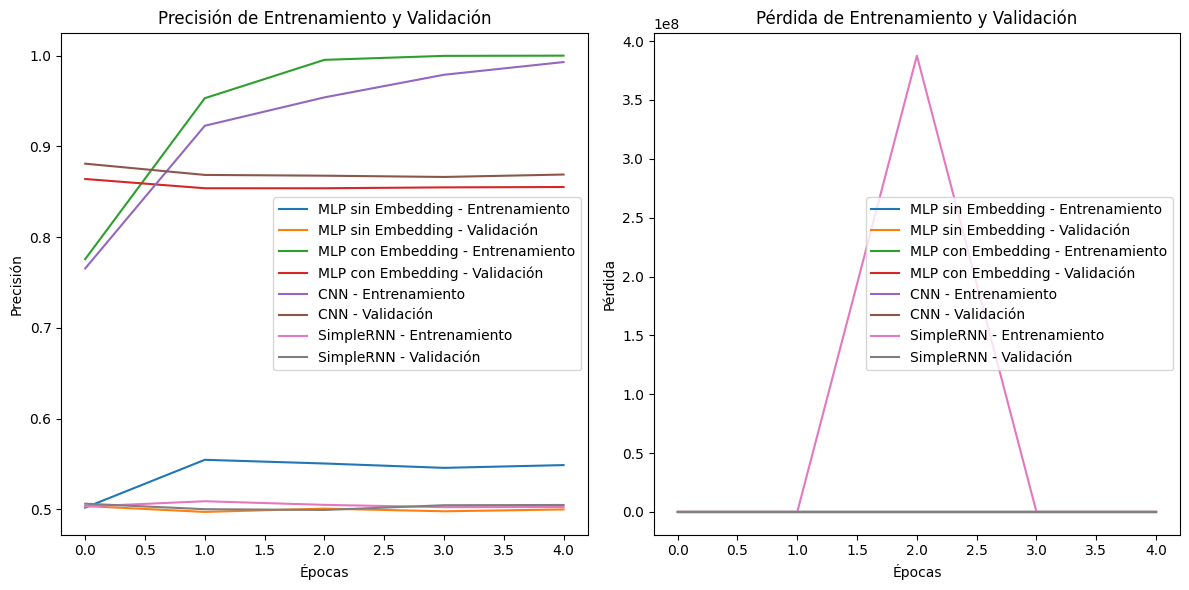

In [15]:
import matplotlib.pyplot as plt


history_model = model.fit(X_train_padded, y_train, validation_data=(X_test_padded, y_test), epochs=5, batch_size=64, verbose=0)
history_model2 = model2.fit(X_train_padded, y_train, validation_data=(X_test_padded, y_test), epochs=5, batch_size=64, verbose=0)
history_model3 = model3.fit(X_train_padded, y_train, validation_data=(X_test_padded, y_test), epochs=5, batch_size=64, verbose=0)
history_model4 = model4.fit(X_train_padded, y_train, validation_data=(X_test_padded, y_test), epochs=5, batch_size=64, verbose=0)


score_model = model.evaluate(X_test_padded, y_test, verbose=0)
score_model2 = model2.evaluate(X_test_padded, y_test, verbose=0)
score_model3 = model3.evaluate(X_test_padded, y_test, verbose=0)
score_model4 = model4.evaluate(X_test_padded, y_test, verbose=0)

print(f"Modelo MLP no Embedding - Precisión: {score_model[1]:.4f}, Pérdida: {score_model[0]:.4f}")
print(f"Modelo MLP si Embedding - Precisión: {score_model2[1]:.4f}, Pérdida: {score_model2[0]:.4f}")
print(f"Modelo CNN - Precisión: {score_model3[1]:.4f}, Pérdida: {score_model3[0]:.4f}")
print(f"Modelo SimpleRNN - Precisión: {score_model4[1]:.4f}, Pérdida: {score_model4[0]:.4f}")


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_model.history['accuracy'], label='MLP sin Embedding - Entrenamiento')
plt.plot(history_model.history['val_accuracy'], label='MLP sin Embedding - Validación')
plt.plot(history_model2.history['accuracy'], label='MLP con Embedding - Entrenamiento')
plt.plot(history_model2.history['val_accuracy'], label='MLP con Embedding - Validación')
plt.plot(history_model3.history['accuracy'], label='CNN - Entrenamiento')
plt.plot(history_model3.history['val_accuracy'], label='CNN - Validación')
plt.plot(history_model4.history['accuracy'], label='SimpleRNN - Entrenamiento')
plt.plot(history_model4.history['val_accuracy'], label='SimpleRNN - Validación')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history_model.history['loss'], label='MLP sin Embedding - Entrenamiento')
plt.plot(history_model.history['val_loss'], label='MLP sin Embedding - Validación')
plt.plot(history_model2.history['loss'], label='MLP con Embedding - Entrenamiento')
plt.plot(history_model2.history['val_loss'], label='MLP con Embedding - Validación')
plt.plot(history_model3.history['loss'], label='CNN - Entrenamiento')
plt.plot(history_model3.history['val_loss'], label='CNN - Validación')
plt.plot(history_model4.history['loss'], label='SimpleRNN - Entrenamiento')
plt.plot(history_model4.history['val_loss'], label='SimpleRNN - Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()


### Discusión:

El modelo CNN fue al que mejor le fue con las métricas puestas para lo de clasificación de texto. Hace total sentido ya que es muy bueno para capturar patrones locales en datos textuales, así como también en n-gramas y frases.

De ahí, le sige el que tiene embedding, este también le fue bien, pero no capturó tanta info importante, lo que se ve en su precisión baja.

Así mismo, también es importante mencionar el tema del resto de modelos, donde podemos analizar por medio del gráfico de forma más clara lo siguiente:

Sin Embedding: Precisión se mantuvo alrededor de 0.5, rendimiento como que si fuera al azar, sin aprendizaje significativo.

Con Embedding: Mejor precisión, alcanzando alrededor de 0.85, tiene efectividad para conocer relaciones semánticas.

CNN: Logra la mejor precisión, aproximadamente 0.87, por su capacidad de ver patrones en las secuencias de texto.

SimpleRNN: Precisión baja casi al azar, muestra dificultades para aprender.

### ¿En qué contextos cree que cada uno de estos modelos podría rendir mejor en algún proyecto de procesamiento de texto?

El MLP sin embedding puede ser útil en contextos donde las características de entrada ya están bien representadas numéricamente y no se necesita capturar la semántica de las palabras, tal vez para contar palabras.

El MLP con embedding puede funcionar en tareas donde la comprensión básica de la relación semántica entre palabras es necesaria. Tal vez cuando se quiera hacer análisis de sentimientos.

Con el CNN, lo podemos usar tal vez para capturar patrones locales en texto, tipo obtener frases, para spam o cosas similares.

Y el modelo SimpleRNN, para textos muy cortos, ya que no creo que funcione en patrones más complejos.